# Experiment 06: Received Signal Strength-Based Base Station Selection

**Course:** Mobile and Cellular Communication Laboratory  
**Course Code:** ICT-4204  
**Department:** Department of Information and Communication Technology, Islamic University, Kushtia, Bangladesh  
**Implementation:** Python / Jupyter Notebook

---
**Course-source basis:** Chapter 4 cell-coverage concepts and William C. Y. Lee RSS/handoff discussion; implementation is a simplified RSS-only selection model.

> This notebook is an educational laboratory implementation. It keeps the mathematical model simple enough to explain in a practical examination while preserving the core cellular-communication ideas.

## Aim

To select the most suitable base station for a moving mobile using received signal strength (RSS).

## Objectives

- Calculate RSS from multiple base stations.
- Compare the received levels at each mobile position.
- Select the base station with the strongest RSS.
- Visualize cell-selection regions along a mobile path.

## Theory

A mobile may receive signals from several nearby base stations. A basic cell-selection rule is to choose the base station with the largest received signal strength:

$$
BS_{\text{selected}}(x)
=
\arg\max_i RSS_i(x)
$$

For this experiment, RSS is modeled with the log-distance relationship

$$
RSS_i(d)=RSS(d_0)-10n\log_{10}\left(\frac{d_i}{d_0}\right)
$$

where:

- $RSS(d_0)$ is the reference received level,
- $d_i$ is distance to base station $i$,
- $n$ is the path-loss exponent.

The course material emphasizes that cell coverage depends on signal strength and distance, and the reference text discusses RSS as a handoff/selection-related measurement. This notebook turns that idea into a simple base-station-selection experiment.

> Real cellular selection additionally uses technology-specific measurements, minimum quality criteria, priorities, and load/control information. The present model intentionally uses RSS only.

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt

# Base stations placed along a straight road
bs_positions_m = np.array([0.0, 500.0, 1000.0])
mobile_positions_m = np.linspace(1, 999, 500)

rss_reference_dbm = -30.0
path_loss_exponent = 3.0

def calculate_rss_dbm(mobile_x_m, bs_x_m, rss_ref_dbm, n):
    distance_m = np.abs(mobile_x_m - bs_x_m)
    distance_m = np.maximum(distance_m, 1.0)
    return rss_ref_dbm - 10 * n * np.log10(distance_m)

rss_matrix = np.array([
    calculate_rss_dbm(
        mobile_positions_m,
        bs_x,
        rss_reference_dbm,
        path_loss_exponent
    )
    for bs_x in bs_positions_m
])

selected_bs = np.argmax(rss_matrix, axis=0) + 1

In [2]:
# Show sample decisions
sample_positions = [100, 300, 500, 700, 900]

for position in sample_positions:
    idx = np.argmin(np.abs(mobile_positions_m - position))
    values = rss_matrix[:, idx]
    print(
        f"At x={mobile_positions_m[idx]:.0f} m: "
        f"RSS={np.round(values, 2)} dBm -> select BS{selected_bs[idx]}"
    )

At x=99 m: RSS=[ -89.87 -108.09 -118.64] dBm -> select BS1
At x=299 m: RSS=[-104.27  -99.1  -115.37] dBm -> select BS2
At x=499 m: RSS=[-110.94  -30.   -111.  ] dBm -> select BS2
At x=699 m: RSS=[-115.33  -98.97 -104.36] dBm -> select BS2
At x=899 m: RSS=[-118.61 -108.03  -90.13] dBm -> select BS3


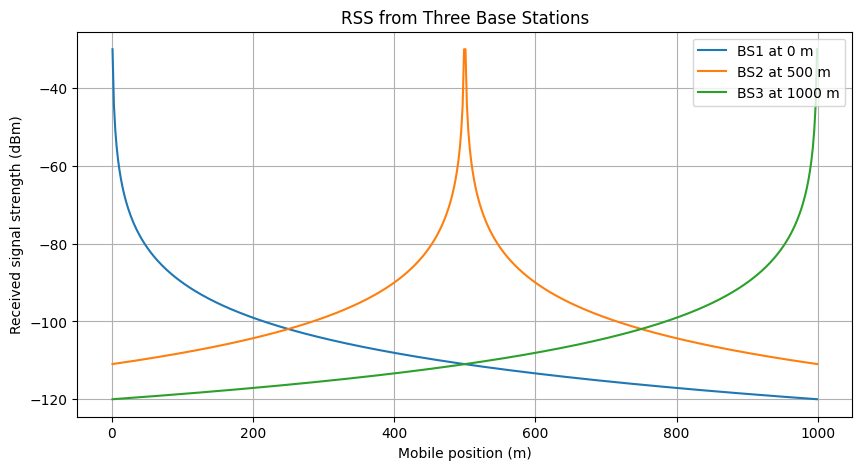

In [3]:
plt.figure(figsize=(10, 5))
for i in range(len(bs_positions_m)):
    plt.plot(
        mobile_positions_m,
        rss_matrix[i],
        label=f"BS{i+1} at {bs_positions_m[i]:.0f} m"
    )

plt.xlabel("Mobile position (m)")
plt.ylabel("Received signal strength (dBm)")
plt.title("RSS from Three Base Stations")
plt.legend()
plt.grid(True)
plt.show()

**Observation:** Each base station dominates the region closest to it. The crossover points occur where two RSS curves become equal.

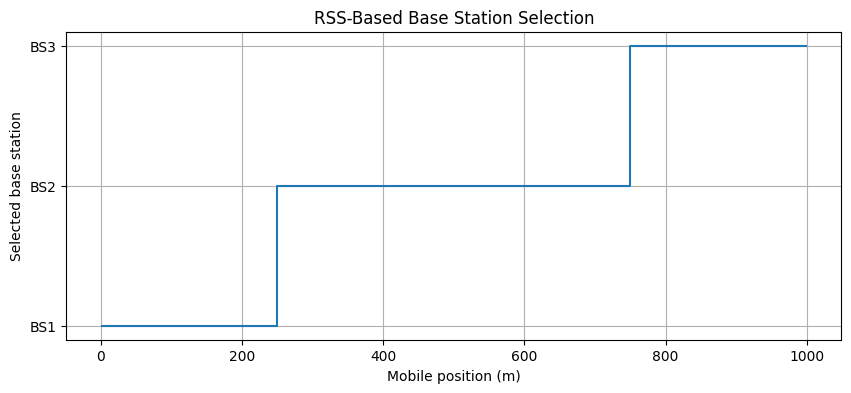

In [4]:
plt.figure(figsize=(10, 4))
plt.step(mobile_positions_m, selected_bs, where="mid")
plt.xlabel("Mobile position (m)")
plt.ylabel("Selected base station")
plt.yticks([1, 2, 3], ["BS1", "BS2", "BS3"])
plt.title("RSS-Based Base Station Selection")
plt.grid(True)
plt.show()

## Result and Discussion

The mobile automatically selects the base station with the strongest modeled RSS. With equally powered and equally spaced base stations in a symmetric environment, the selection boundaries occur close to the midpoints between neighboring sites.

## Conclusion

RSS-based base-station selection was implemented successfully using a simple log-distance propagation model.

## Viva Questions and Short Answers

1. **What is RSS?**  
   Received Signal Strength, usually expressed in dBm.

2. **What selection rule is used here?**  
   Choose the base station with the maximum RSS.

3. **Why does RSS decrease with distance?**  
   Propagation loss increases as the transmitter-receiver separation increases.

4. **What does the path-loss exponent represent?**  
   How rapidly average received power decreases with distance in the environment.

5. **Why is RSS-only selection simplified?**  
   Real networks also consider quality, interference, priorities, load, and protocol rules.